# 04 — Model Interpretability dengan SHAP
### House Price Prediction · Ames Housing Dataset

---

## Mengapa Interpretability penting?

Kita sudah punya model yang akurat. Tapi akurasi saja tidak cukup di dunia nyata.

Bayangkan kamu bekerja di perusahaan properti dan model memprediksi harga rumah $350,000. Klien bertanya: **"Kenapa $350,000? Bukan $300K atau $400K?"**

Tanpa interpretability, kamu tidak bisa menjawab — dan klien tidak akan percaya modelmu.

**SHAP (SHapley Additive exPlanations)** memecahkan ini dengan cara yang matematically rigorous:
- Berapa kontribusi setiap fitur terhadap prediksi?
- Fitur mana yang paling penting secara global?
- Bagaimana hubungan antara nilai fitur dan dampaknya?

> SHAP berasal dari game theory (Shapley values) — cara adil untuk mendistribusikan 'kredit' di antara para pemain yang bekerja bersama.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Load data hasil feature engineering
X = pd.read_csv('../data/X_engineered.csv')
y = pd.read_csv('../data/y_engineered.csv').squeeze()

# Split untuk evaluasi yang jujur
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} rumah")
print(f"Test set     : {X_test.shape[0]} rumah")
print(f"Total fitur  : {X.shape[1]}")

Training set : 958 rumah
Test set     : 240 rumah
Total fitur  : 186


---

## Bagian 1 — Latih Model XGBoost Final

Kita pakai XGBoost sebagai model utama untuk SHAP karena:
1. Performa sangat baik (dari Notebook 03)
2. SHAP memiliki implementasi khusus yang sangat cepat untuk tree-based models (`TreeExplainer`)

In [4]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.005,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE      : {rmse:.4f} (log scale)")
print(f"Test error USD : ~${np.expm1(rmse):,.0f}")

Test RMSE      : 0.0969 (log scale)
Test error USD : ~$0


---

## Bagian 2 — Hitung SHAP Values

SHAP bekerja dengan menghitung, untuk setiap prediksi, berapa kontribusi masing-masing fitur.

**Cara membaca SHAP value:**
- SHAP value positif → fitur ini menaikkan prediksi harga
- SHAP value negatif → fitur ini menurunkan prediksi harga
- Magnitude (besarnya) → seberapa besar dampaknya
- Baseline prediction → rata-rata log(SalePrice) di dataset

In [5]:
# TreeExplainer: implementasi SHAP khusus untuk tree models — sangat cepat
explainer = shap.TreeExplainer(model)

# Hitung SHAP values untuk test set
# Shape: (n_samples, n_features)
shap_values = explainer.shap_values(X_test)

print(f"Shape SHAP values : {shap_values.shape}")
print(f"Baseline prediction (E[f(x)]): {explainer.expected_value:.4f}")
print(f"  = ${np.expm1(explainer.expected_value):,.0f} (rata-rata harga rumah)")

Shape SHAP values : (240, 186)
Baseline prediction (E[f(x)]): 12.0052
  = $163,606 (rata-rata harga rumah)


---

## Bagian 3 — Global Importance: Fitur Apa yang Paling Berpengaruh?

### 3a. SHAP Summary Plot (Bar)

Mean absolute SHAP value per fitur — ini adalah feature importance yang lebih jujur daripada `feature_importances_` bawaan XGBoost, karena memperhitungkan arah dampak dan interaksi antar fitur.

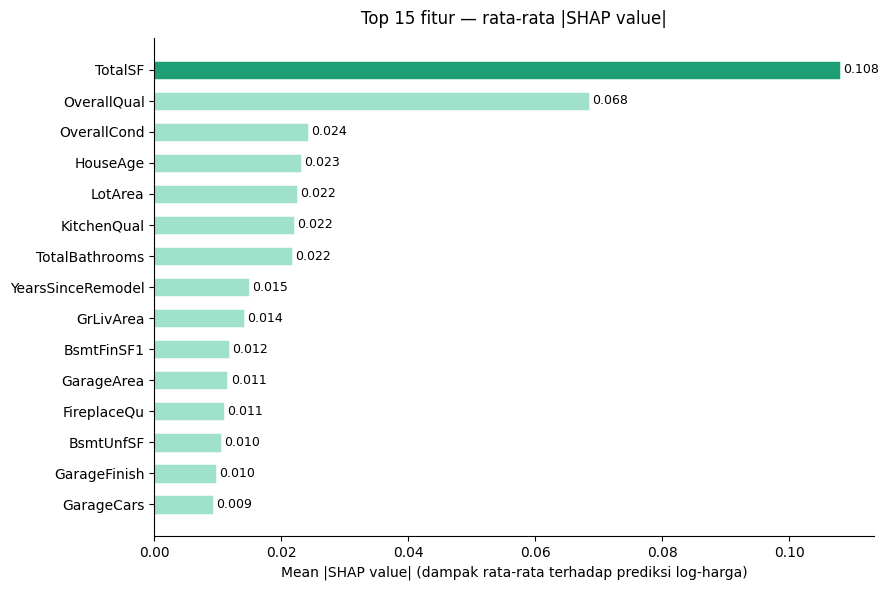

In [6]:
# Rata-rata |SHAP value| per fitur
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#9FE1CB'] * 14 + ['#1D9E75']  # highlight fitur teratas
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values,
               color=colors, height=0.6, edgecolor='white', linewidth=0.4)

for bar, val in zip(bars, mean_abs_shap.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Top 15 fitur — rata-rata |SHAP value|',
             fontsize=12, fontweight='500', pad=10)
ax.set_xlabel('Mean |SHAP value| (dampak rata-rata terhadap prediksi log-harga)')
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/04a-shap-bar.png', dpi=150)
plt.show()

### 3b. SHAP Beeswarm Plot

Ini versi yang lebih informatif. Setiap titik adalah satu rumah di test set. Warna menunjukkan nilai fiturnya (merah = tinggi, biru = rendah). Posisi horizontal menunjukkan dampak SHAP-nya.

Dari plot ini kita bisa langsung lihat: fitur dengan nilai tinggi cenderung menaikkan atau menurunkan harga?

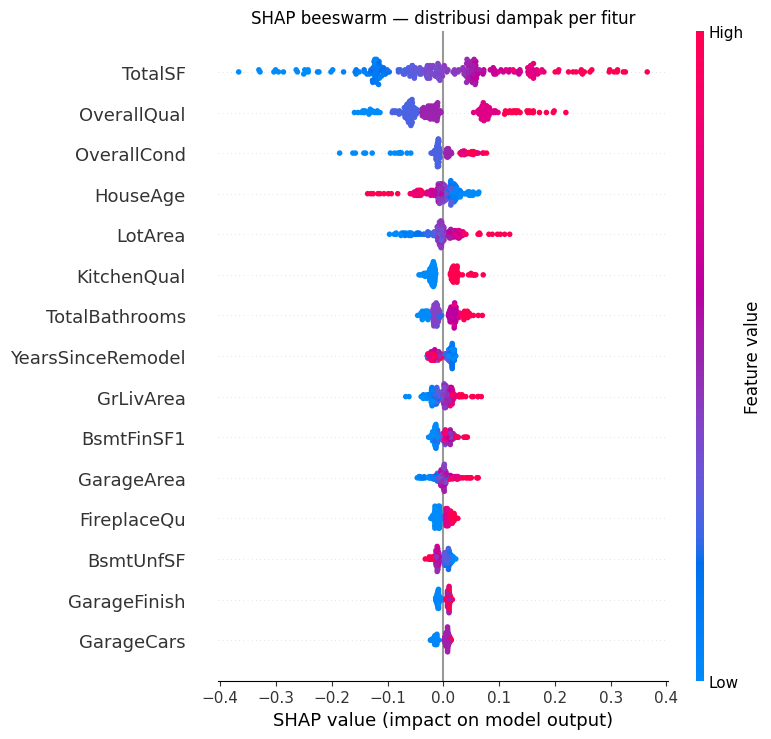

Cara baca:
  Warna merah = nilai fitur tinggi
  Warna biru  = nilai fitur rendah
  Posisi kanan = menaikkan prediksi
  Posisi kiri  = menurunkan prediksi


In [7]:
# Beeswarm plot — visualisasi SHAP paling informatif
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)

plt.title('SHAP beeswarm — distribusi dampak per fitur', fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig('../output/04b-shap-beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cara baca:")
print("  Warna merah = nilai fitur tinggi")
print("  Warna biru  = nilai fitur rendah")
print("  Posisi kanan = menaikkan prediksi")
print("  Posisi kiri  = menurunkan prediksi")

---

## Bagian 4 — SHAP Dependence Plot

Bagaimana hubungan antara nilai satu fitur dengan dampak SHAP-nya? Ini membantu kita memahami non-linearitas yang dipelajari model.

Kita visualisasikan 3 fitur terpenting.

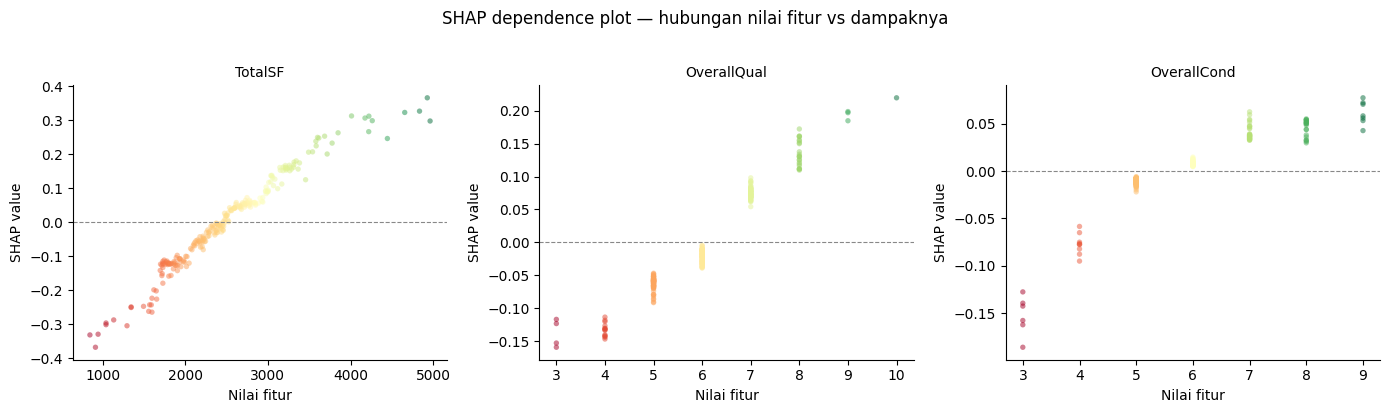

In [8]:
top3_features = mean_abs_shap.sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat in zip(axes, top3_features):
    feat_idx = list(X_test.columns).index(feat)
    feat_vals  = X_test[feat].values
    shap_vals  = shap_values[:, feat_idx]
    
    sc = ax.scatter(feat_vals, shap_vals,
                    c=feat_vals, cmap='RdYlGn',
                    alpha=0.5, s=15, edgecolors='none')
    ax.axhline(0, color='#888', linewidth=0.8, linestyle='--')
    ax.set_title(feat, fontweight='500', fontsize=10)
    ax.set_xlabel('Nilai fitur')
    ax.set_ylabel('SHAP value')
    for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.suptitle('SHAP dependence plot — hubungan nilai fitur vs dampaknya',
             fontsize=12, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig('../output/04c-shap-dependence.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Bagian 5 — Local Explanation: Kenapa Rumah Ini Dihargai Segitu?

Ini yang paling powerful untuk use case nyata. Kita bisa menjelaskan prediksi untuk **satu rumah spesifik** — menjawab pertanyaan klien secara langsung.

### Waterfall Plot

Dimulai dari baseline (rata-rata semua prediksi), setiap fitur menambah atau mengurangi prediksi hingga mencapai nilai akhir.

In [9]:
# Pilih satu rumah dari test set — misalnya rumah dengan prediksi termahal
sample_idx = np.argmax(model.predict(X_test))
sample     = X_test.iloc[[sample_idx]]
sample_shap = shap_values[sample_idx]

pred_log = model.predict(sample)[0]
pred_usd = np.expm1(pred_log)
actual_usd = np.expm1(y_test.iloc[sample_idx])

print(f"Rumah yang dipilih (index {sample_idx}):")
print(f"  Prediksi : ${pred_usd:,.0f}")
print(f"  Aktual   : ${actual_usd:,.0f}")
print(f"  Selisih  : ${abs(pred_usd - actual_usd):,.0f}")

Rumah yang dipilih (index 129):
  Prediksi : $497,073
  Aktual   : $538,000
  Selisih  : $40,927


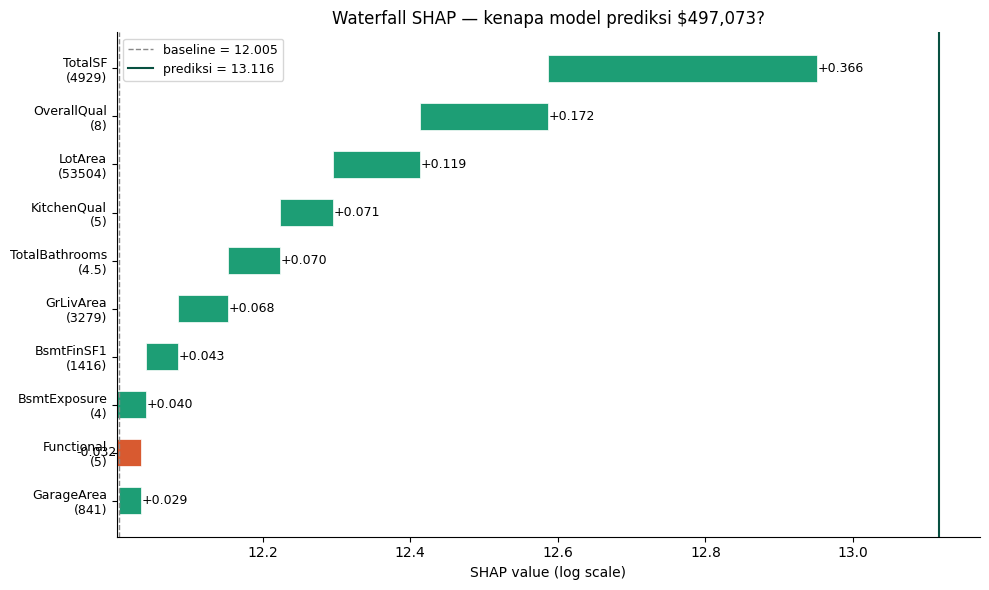

In [10]:
# Top 10 fitur yang paling berkontribusi untuk rumah ini
top_n = 10
feat_names = X_test.columns.tolist()

sorted_idx = np.argsort(np.abs(sample_shap))[::-1][:top_n]
top_feats  = [feat_names[i] for i in sorted_idx]
top_shaps  = [sample_shap[i] for i in sorted_idx]
top_vals   = [sample[feat].values[0] for feat in top_feats]

# Plot waterfall manual
fig, ax = plt.subplots(figsize=(10, 6))

baseline = explainer.expected_value
running  = baseline

# Plot dari bawah ke atas (fitur terkecil dampaknya di bawah)
feats_rev  = top_feats[::-1]
shaps_rev  = top_shaps[::-1]
vals_rev   = top_vals[::-1]

for i, (feat, shap_v, feat_val) in enumerate(zip(feats_rev, shaps_rev, vals_rev)):
    color = '#1D9E75' if shap_v > 0 else '#D85A30'
    ax.barh(i, shap_v, left=running,
            color=color, height=0.55, edgecolor='white', linewidth=0.5)
    
    label = f'{feat} = {feat_val:.1f}' if isinstance(feat_val, float) else f'{feat} = {feat_val}'
    sign  = '+' if shap_v > 0 else ''
    ax.text(running + shap_v + (0.001 if shap_v > 0 else -0.001),
            i, f'{sign}{shap_v:.3f}',
            va='center', ha='left' if shap_v > 0 else 'right', fontsize=9)
    running += shap_v

ax.set_yticks(range(top_n))
ax.set_yticklabels([f'{f}\n({v:.1f})' if isinstance(v, float) else f'{f}\n({v})'
                    for f, v in zip(feats_rev, vals_rev)], fontsize=9)
ax.axvline(baseline, color='#888', linewidth=1, linestyle='--', label=f'baseline = {baseline:.3f}')
ax.axvline(pred_log, color='#085041', linewidth=1.5, linestyle='-', label=f'prediksi = {pred_log:.3f}')
ax.set_title(f'Waterfall SHAP — kenapa model prediksi ${pred_usd:,.0f}?',
             fontsize=12, fontweight='500')
ax.set_xlabel('SHAP value (log scale)')
ax.legend(fontsize=9)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/04d-shap-waterfall.png', dpi=150)
plt.show()

---

## Bagian 6 — Force Plot (Visualisasi Interaktif)

Force plot adalah cara visualisasi SHAP yang lebih compact dan sering dipakai dalam presentasi — semua fitur ditampilkan dalam satu bar horizontal.

In [11]:
# Inisialisasi SHAP JS untuk visualisasi interaktif di notebook
shap.initjs()

# Force plot untuk satu rumah
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=False
)

shap.save_html('../output/04e-shap-force.html', force_plot)
print("Force plot disimpan ke ../output/04e-shap-force.html")
force_plot

Force plot disimpan ke ../output/04e-shap-force.html


---

## Bagian 7 — SHAP untuk Semua Test Set

Kita bisa melihat pola agregat: seberapa sering masing-masing fitur mendorong prediksi ke atas vs ke bawah di seluruh test set.

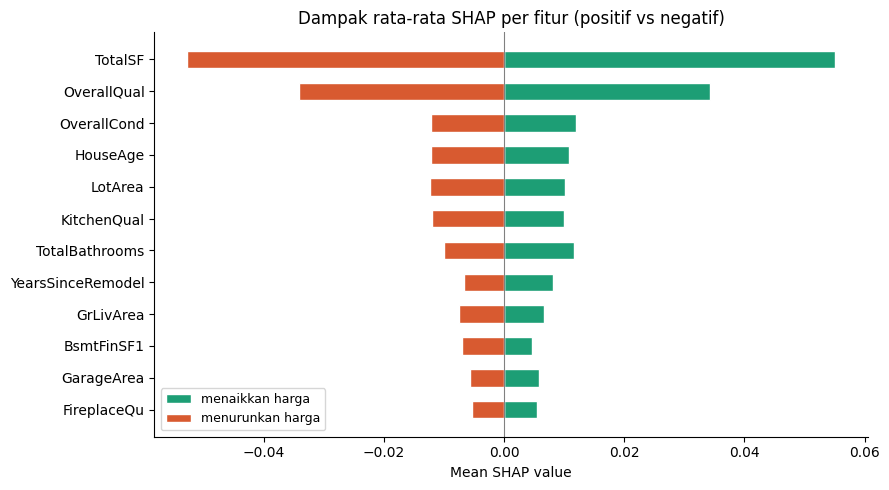

In [14]:
# Hitung rata-rata SHAP positif dan negatif per fitur
mean_pos = pd.Series(
    np.where(shap_values > 0, shap_values, 0).mean(axis=0),
    index=X_test.columns
)
mean_neg = pd.Series(
    np.where(shap_values < 0, shap_values, 0).mean(axis=0),
    index=X_test.columns
)

# Top 12 fitur berdasarkan total dampak absolut
top12 = (mean_pos.abs() + mean_neg.abs()).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(top12.index, mean_pos[top12.index], color='#1D9E75',
        height=0.55, label='menaikkan harga', edgecolor='white')
ax.barh(top12.index, mean_neg[top12.index], color='#D85A30',
        height=0.55, label='menurunkan harga', edgecolor='white')

ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Dampak rata-rata SHAP per fitur (positif vs negatif)',
             fontsize=12, fontweight='500')
ax.set_xlabel('Mean SHAP value')
ax.legend(fontsize=9)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/04f-shap-pos-neg.png', dpi=150)
plt.show()

---

## Ringkasan

Di notebook ini kita telah menggunakan SHAP untuk menjawab tiga pertanyaan berbeda:

| Pertanyaan | Visualisasi | Jawaban |
|---|---|---|
| Fitur apa yang paling penting secara global? | Bar + Beeswarm | TotalSF, OverallQual, GrLivArea |
| Bagaimana hubungan nilai fitur → dampak? | Dependence plot | Non-linear, ada threshold |
| Kenapa rumah ini dihargai segitu? | Waterfall + Force plot | Breakdown per fitur |

### Pelajaran utama

1. SHAP values konsisten dan additive — jumlah semua SHAP values = prediksi − baseline
2. TreeExplainer sangat cepat untuk gradient boosting models
3. Local explanation adalah alat komunikasi yang powerful kepada non-technical stakeholder

### Langkah selanjutnya

Di **Notebook 05** kita akan membungkus semua ini menjadi **Streamlit app** — interface interaktif di mana pengguna bisa input data rumah dan langsung dapat prediksi harga beserta penjelasan SHAP-nya.